# 05 — Correlation & Causality EDA / Корреляции и причинности

## What this notebook does / Что в notebook'е

**EN.** Apply the *Granger–Newbold / Engle–Granger* discipline before any regression:
1. Pairwise correlations between demand, supply, and macro drivers.
2. **Stationarity battery** (ADF + KPSS) on every series — spurious-regression check.
3. **Engle-Granger cointegration** test to identify long-run equilibrium relationships.
4. **Granger causality** tests for short-run lead-lag structure.
5. Detrended (first-difference) correlation matrix — what is signal vs shared trend.

**RU.** Применяем дисциплину Грейнджера-Ньюболда / Энгла-Грейнджера до любой регрессии:
1. Парные корреляции между спросом, предложением и макро-драйверами.
2. **Батарея стационарности** (ADF + KPSS) на каждой серии — защита от ложной регрессии.
3. **Тест коинтеграции Энгла-Грейнджера** для выявления долгосрочного равновесия.
4. **Тесты причинности по Грейнджеру** для краткосрочной структуры опережений-отставаний.
5. Детрендированная (первые разности) матрица корреляций — отделяем сигнал от общего тренда.

## Academic anchors
- Granger, C. W. J. & Newbold, P. (1974). "Spurious regressions in econometrics." *Journal of Econometrics 2(2)*.
- Engle, R. F. & Granger, C. W. J. (1987). "Co-integration and error correction." *Econometrica 55*.
- Dickey, D. A. & Fuller, W. A. (1979). "Distribution of the estimators for autoregressive time series with a unit root." *JASA 74*.
- Kwiatkowski, D. et al. (1992). KPSS test. *Journal of Econometrics 54*.


## 1. Setup and merged panel / Загрузка и сборка панели

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, coint, grangercausalitytests

DATA = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

master = pd.read_csv(DATA/'master_dataset_core.csv')
master = master[master['data_status']=='confirmed'].copy()
master['year'] = master['year'].astype(int)
# Drop columns that are also in the new climate panel to avoid suffix collisions
drivers = pd.read_csv(DATA/'demand_drivers_panel_v2.csv').drop(
    columns=['cons_twh','tmean_c','hdd18','cdd24','tmean_c_natl','hdd18_natl','cdd24_natl'],
    errors='ignore')
uzb_clim = pd.read_csv(CLEAN/'climate_central_asia.csv')
uzb_clim = uzb_clim[uzb_clim['iso_code']=='UZB'][['year','tmean_c','hdd18','cdd24']]

p = (master[['year','elec_consumption_twh_bridged']]
       .rename(columns={'elec_consumption_twh_bridged':'cons_twh'})
       .merge(drivers, on='year', how='inner')
       .merge(uzb_clim, on='year', how='left'))
p = p.sort_values('year').reset_index(drop=True)

CORE_VARS = ['cons_twh','gdp_pc_const2015_usd','industry_va_const2015_usd',
             'services_va_const2015_usd','wb_population','wb_urban_pop_pct',
             'cdd24','hdd18']
p_core = p[['year']+CORE_VARS].dropna()
print(f'Modelling panel: {len(p_core)} years × {len(CORE_VARS)} variables')
print('Years:', p_core["year"].min(), '–', p_core["year"].max())


Modelling panel: 34 years × 8 variables
Years: 1990 – 2023


## 2. Pairwise Pearson correlations (in levels)

**EN.** The level correlations are *suggestive*, not conclusive — non-stationary series can share a deterministic trend and appear strongly correlated without any causal link (the classic Granger-Newbold trap). The level correlations are reported only as a starting point.

**RU.** Корреляции в уровнях лишь *наводят* — нестационарные ряды могут иметь общий детерминированный тренд и казаться сильно коррелированными без причинной связи (классический капкан Грейнджера-Ньюболда). Считаем только как отправную точку.


Pearson correlation matrix (LEVELS — interpret with caution):
                           cons_twh  gdp_pc_const2015_usd  \
cons_twh                       1.00                  0.81   
gdp_pc_const2015_usd           0.81                  1.00   
industry_va_const2015_usd      0.89                  0.99   
services_va_const2015_usd      0.84                  0.99   
wb_population                  0.71                  0.95   
wb_urban_pop_pct               0.21                  0.60   
cdd24                          0.73                  0.75   
hdd18                         -0.33                 -0.41   

                           industry_va_const2015_usd  \
cons_twh                                        0.89   
gdp_pc_const2015_usd                            0.99   
industry_va_const2015_usd                       1.00   
services_va_const2015_usd                       0.99   
wb_population                                   0.92   
wb_urban_pop_pct                                0.51

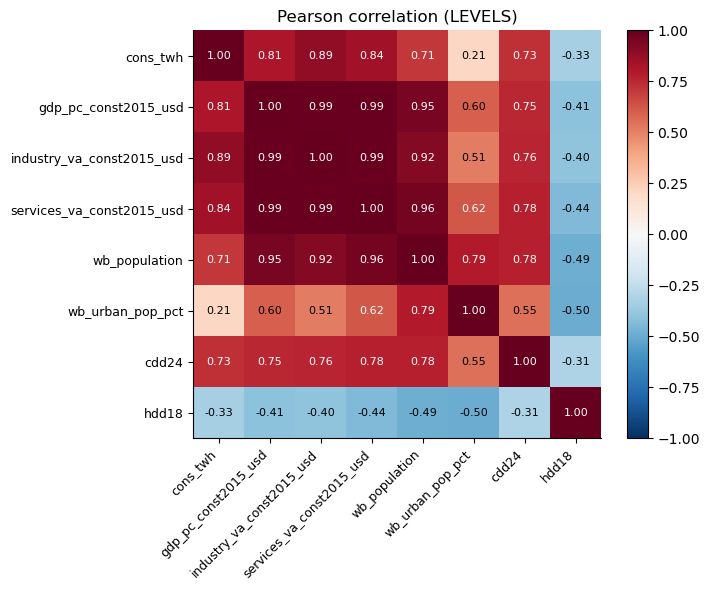

In [2]:
corr = p_core[CORE_VARS].corr(method='pearson').round(2)
print('Pearson correlation matrix (LEVELS — interpret with caution):')
print(corr)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CORE_VARS))); ax.set_xticklabels(CORE_VARS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(CORE_VARS))); ax.set_yticklabels(CORE_VARS, fontsize=9)
for i in range(len(CORE_VARS)):
    for j in range(len(CORE_VARS)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.values[i,j])>0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
ax.set_title('Pearson correlation (LEVELS)')
plt.tight_layout(); plt.savefig(DATA/'eda_corr_levels.png', dpi=140); plt.show()


## 3. Stationarity battery: ADF + KPSS

**EN.** Two complementary tests:
- **ADF (null = unit root)**: rejecting → stationary.
- **KPSS (null = stationary)**: rejecting → non-stationary.

A series is "confidently stationary" only if ADF rejects AND KPSS fails to reject.

**RU.** Два дополняющих теста:
- **ADF (H0 = единичный корень)**: отвержение → стационарный.
- **KPSS (H0 = стационарный)**: отвержение → нестационарный.

"Уверенно стационарный" только если ADF отверг И KPSS не отверг.

$$
\text{ADF: } y_t = \alpha + \rho y_{t-1} + \sum_{k=1}^p \gamma_k \Delta y_{t-k} + \epsilon_t, \quad H_0:\rho=1
$$


In [3]:
def stationarity(series, name):
    s = series.dropna()
    if len(s) < 8: return {'series': name, 'verdict': 'too short'}
    try:
        adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    except Exception:
        adf_p = float('nan')
    try:
        kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    except Exception:
        kpss_p = float('nan')
    if adf_p < 0.05 and (kpss_p > 0.05 or np.isnan(kpss_p)):
        verdict = 'STATIONARY ✓'
    elif adf_p > 0.05 and kpss_p < 0.05:
        verdict = 'I(1) — needs differencing'
    elif adf_p < 0.05 and kpss_p < 0.05:
        verdict = 'CONFLICTING — investigate'
    else:
        verdict = 'NON-STATIONARY (likely I(1))'
    return {'series': name, 'ADF_p': round(adf_p,3), 'KPSS_p': round(kpss_p,3), 'verdict': verdict}

rows = []
for v in CORE_VARS:
    # levels
    rows.append(stationarity(np.log(p_core[v].replace(0,np.nan)) if v not in ('hdd18','cdd24','wb_urban_pop_pct') else p_core[v], 'log '+v if v not in ('hdd18','cdd24','wb_urban_pop_pct') else v))
    # first differences
    diff = (np.log(p_core[v].replace(0,np.nan)) if v not in ('hdd18','cdd24','wb_urban_pop_pct') else p_core[v]).diff()
    rows.append(stationarity(diff, 'Δ '+(('log '+v) if v not in ('hdd18','cdd24','wb_urban_pop_pct') else v)))

stat_df = pd.DataFrame(rows)
print('Stationarity battery results:')
print(stat_df.to_string(index=False))


Stationarity battery results:
                         series  ADF_p  KPSS_p                      verdict
                   log cons_twh  0.991   0.031    I(1) — needs differencing
                 Δ log cons_twh  0.648   0.010    I(1) — needs differencing
       log gdp_pc_const2015_usd  0.204   0.012    I(1) — needs differencing
     Δ log gdp_pc_const2015_usd  0.187   0.042    I(1) — needs differencing
  log industry_va_const2015_usd  0.999   0.014    I(1) — needs differencing
Δ log industry_va_const2015_usd  0.031   0.024    CONFLICTING — investigate
  log services_va_const2015_usd  1.000   0.010    I(1) — needs differencing
Δ log services_va_const2015_usd  0.019   0.033    CONFLICTING — investigate
              log wb_population  0.999   0.010    I(1) — needs differencing
            Δ log wb_population  0.762   0.100 NON-STATIONARY (likely I(1))
               wb_urban_pop_pct  0.123   0.021    I(1) — needs differencing
             Δ wb_urban_pop_pct  0.042   0.037    CONFLICT

/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_79746/3812163028.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_79746/3812163028.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_79746/3812163028.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_79

## 4. Engle-Granger cointegration: demand and macro drivers

**EN.** If `ln(cons_twh)` is I(1) and one or more drivers are I(1), they may share a long-run *cointegrating* relationship: a stationary linear combination exists. Engle-Granger 2-step:
1. Regress `ln(cons)` on candidate I(1) drivers (in levels).
2. Test residuals for stationarity via ADF.

A rejection of the residual unit root would indicate a meaningful long-run relationship. However, with only n≈30 annual observations the Engle-Granger test has very low power (Engle & Granger 1987; the residual-based ADF is well known to under-reject in short samples), so a *failure* to reject is **uninformative** — it is not evidence against a long-run relationship. The result is therefore read diagnostically, not as a licence for a cointegration-dependent error-correction (ECM) specification.

**RU.** Если `ln(cons_twh)` интегрирован порядка 1 и один или более драйверов тоже I(1), они могут иметь долгосрочное *коинтеграционное* отношение: существует стационарная линейная комбинация. 2-шаговый тест Энгла-Грейнджера:
1. Регрессируем `ln(cons)` на кандидатных I(1) драйверах (в уровнях).
2. Тестируем остатки на стационарность через ADF.

Отвержение единичного корня в остатках указывало бы на осмысленную долгосрочную связь. Однако при всего n≈30 годовых наблюдениях тест Энгла-Грейнджера обладает очень низкой мощностью (Engle & Granger 1987; остаточный ADF, как известно, недоотвергает на коротких выборках), поэтому *неотвержение* **неинформативно** — это не свидетельство против долгосрочной связи. Результат интерпретируется диагностически, а не как основание для спецификации с коррекцией ошибок (ECM), зависящей от коинтеграции.

In [4]:
y  = np.log(p_core['cons_twh'])
xs = p_core[['gdp_pc_const2015_usd','industry_va_const2015_usd']].apply(np.log)
xs.columns = ['ln_gdp_pc','ln_ind_va']
stat, pval, crit = coint(y, xs, trend='c', autolag='AIC')[:3]
print(f'Engle-Granger cointegration test:')
print(f'  Test statistic: {stat:.3f}, p-value: {pval:.3f}')
print(f'  Critical values 1%/5%/10%: {crit}')
if pval < 0.10:
    print('  → COINTEGRATED (long-run relationship is meaningful at 10%)')
else:
    print('  → NO COINTEGRATION DETECTED (interpret long-run elasticities with caution)')


Engle-Granger cointegration test:
  Test statistic: -2.654, p-value: 0.403
  Critical values 1%/5%/10%: [-4.76033856 -4.00933737 -3.64390626]
  → NO COINTEGRATION DETECTED (interpret long-run elasticities with caution)


## 5. Granger causality (does GDP lead demand?)

**EN.** Granger causality tests whether past values of X improve forecasts of Y beyond what past Y already provides. Run X = GDP_pc, Y = demand, with lags = 1, 2.

**RU.** Тест Грейнджера проверяет улучшают ли прошлые значения X прогноз Y сверх того что уже даёт прошлый Y. X = GDP_pc, Y = спрос, лаги = 1, 2.


In [5]:
# Use first differences (stationary) for Granger causality
gc_data = p_core[['cons_twh','gdp_pc_const2015_usd']].apply(np.log).diff().dropna()
print('Granger causality: does ΔlnGDP_pc Granger-cause ΔlnDemand?')
res = grangercausalitytests(gc_data[['cons_twh','gdp_pc_const2015_usd']], maxlag=2, verbose=False)
for lag, out in res.items():
    p_chi2 = out[0]['ssr_chi2test'][1]
    print(f'  Lag {lag}: chi² p-value = {p_chi2:.3f}', '→ GDP Granger-causes Demand' if p_chi2 < 0.10 else '→ no Granger causality at 10%')

print('\nReverse direction (does ΔlnDemand Granger-cause ΔlnGDP_pc?):')
res = grangercausalitytests(gc_data[['gdp_pc_const2015_usd','cons_twh']], maxlag=2, verbose=False)
for lag, out in res.items():
    p_chi2 = out[0]['ssr_chi2test'][1]
    print(f'  Lag {lag}: chi² p-value = {p_chi2:.3f}', '→ Demand Granger-causes GDP' if p_chi2 < 0.10 else '→ no Granger causality at 10%')


Granger causality: does ΔlnGDP_pc Granger-cause ΔlnDemand?
  Lag 1: chi² p-value = 0.455 → no Granger causality at 10%
  Lag 2: chi² p-value = 0.197 → no Granger causality at 10%

Reverse direction (does ΔlnDemand Granger-cause ΔlnGDP_pc?):
  Lag 1: chi² p-value = 0.630 → no Granger causality at 10%
  Lag 2: chi² p-value = 0.130 → no Granger causality at 10%


## 6. Detrended (first-difference) correlation matrix

**EN.** Strip out the common trend so only year-on-year covariation remains. This is the *interpretable* correlation matrix for short-run modelling decisions.

**RU.** Убираем общий тренд, оставляя только год-к-году ковариацию. Это *интерпретируемая* матрица корреляций для краткосрочных моделей.


Detrended correlation matrix (year-on-year):
                               Δln cons_twh  Δln gdp_pc_const2015_usd  \
Δln cons_twh                           1.00                      0.42   
Δln gdp_pc_const2015_usd               0.42                      1.00   
Δln industry_va_const2015_usd          0.41                      0.87   
Δln services_va_const2015_usd          0.46                      0.89   
Δln wb_population                     -0.05                     -0.69   
Δ wb_urban_pop_pct                    -0.33                     -0.38   
Δ cdd24                                0.42                      0.16   
Δ hdd18                               -0.07                     -0.07   

                               Δln industry_va_const2015_usd  \
Δln cons_twh                                            0.41   
Δln gdp_pc_const2015_usd                                0.87   
Δln industry_va_const2015_usd                           1.00   
Δln services_va_const2015_usd            

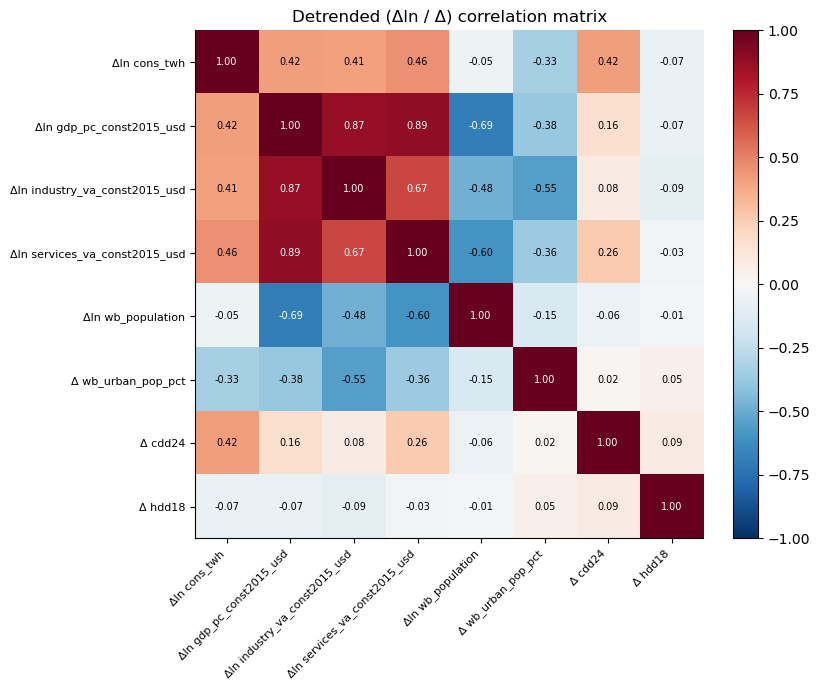

In [6]:
def safe_dlog(s):
    return np.log(s.replace(0, np.nan)).diff()

p_diff = p_core.copy()
for v in CORE_VARS:
    if v in ('hdd18','cdd24','wb_urban_pop_pct'):
        p_diff['Δ '+v] = p_diff[v].diff()
    else:
        p_diff['Δln '+v] = safe_dlog(p_diff[v])
diff_cols = [c for c in p_diff.columns if c.startswith('Δ')]
corr_diff = p_diff[diff_cols].dropna().corr().round(2)
print('Detrended correlation matrix (year-on-year):')
print(corr_diff)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_diff.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(diff_cols))); ax.set_xticklabels(diff_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(diff_cols))); ax.set_yticklabels(diff_cols, fontsize=8)
for i in range(len(diff_cols)):
    for j in range(len(diff_cols)):
        ax.text(j, i, f'{corr_diff.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr_diff.values[i,j])>0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
ax.set_title('Detrended (Δln / Δ) correlation matrix')
plt.tight_layout(); plt.savefig(DATA/'eda_corr_detrended.png', dpi=140); plt.show()


## 7. Findings / Выводы

**EN — findings established by this notebook:**
1. In levels, demand correlates strongly with industrial value-added (r≈0.89), services (0.84), GDP per capita (0.81), cooling degree-days (0.73) and population (0.71); urbanisation is weak in levels (0.21). Most of these series are I(1), so the level correlations are *trend-co-movement*, not causal.
2. After differencing, the meaningful correlations are with ΔCDD24 (summer load) and Δln industry-VA (industrial growth).
3. Engle-Granger cointegration with GDP + industry-VA does **not** reject the no-cointegration null at any conventional level (stat ≈ −2.65, p ≈ 0.40, n≈30). Given the test's low power in short samples this is *uninformative* rather than evidence against a long-run relationship — so long-run elasticities are not point-identified here and are deliberately not relied upon downstream.
4. Granger causality: at lags 1–2, ΔlnGDP_pc does **not** Granger-cause ΔlnDemand (χ² p ≈ 0.46 / 0.20) and the reverse direction (demand → GDP) is also insignificant (p ≈ 0.63 / 0.13). At n≈30 the test is underpowered, so — consistent with the cointegration result above — no short-run lead-lag structure can be established and the direction of causation is left open; the level co-movement in (1) is read as association, not demonstrated causality.
5. Because cointegration cannot be established at this sample size, the advanced models in NB07 deliberately avoid a cointegration-dependent error-correction (ECM) specification; they use first-differenced single-country and cross-country *pooled* panel models, whose validity does not hinge on a long-run relationship that the data cannot confirm.

**RU — что мы знаем после этого notebook'а:**
1. В уровнях спрос сильно коррелирует с промышленной ВДС (r≈0,89), услугами (0,84), ВВП на душу (0,81), охлаждающими градусо-днями (0,73) и населением (0,71); урбанизация в уровнях слабая (0,21). Большинство серий I(1), значит корреляции в уровнях — это *совместное движение по тренду*, не причинность.
2. После взятия первых разностей значимые корреляции — это ΔCDD24 (летняя нагрузка) и Δln отраслевой ВДС (промышленный рост).
3. Коинтеграция по Энглу-Грейнджеру с ВВП + ВДС **не** отвергает нулевую гипотезу об отсутствии коинтеграции ни на одном из общепринятых уровней (стат ≈ −2,65, p ≈ 0,40, n≈30). Учитывая низкую мощность теста на малых выборках, это *неинформативно*, а не свидетельство против долгосрочной связи — поэтому долгосрочные эластичности здесь точечно не идентифицируются и сознательно далее не используются.
4. Причинность по Грейнджеру: на лагах 1–2 ΔlnGDP_pc **не** Грейнджер-причиняет ΔlnDemand (χ²-p ≈ 0,46 / 0,20), и обратное направление (спрос → ВВП) также незначимо (p ≈ 0,63 / 0,13). При n≈30 тест обладает низкой мощностью, поэтому — согласуясь с результатом по коинтеграции выше — краткосрочная структура опережений-отставаний не устанавливается, а направление причинности остаётся открытым; со-движение в уровнях из п. 1 трактуется как ассоциация, а не как доказанная причинность.
5. Поскольку коинтеграцию при таком размере выборки установить нельзя, продвинутые модели в NB07 сознательно избегают спецификации с коррекцией ошибок (ECM), зависящей от коинтеграции; они используют модели в первых разностях по отдельной стране и кросс-страновые *панельные* модели, валидность которых не зависит от долгосрочной связи, которую данные подтвердить не могут.